<a href="https://colab.research.google.com/github/formacionCDIA/cursoCDIA/blob/main/Notebooks/3_Datos_faltantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Análisis de datos y aprendizaje automatizado**
---
# **3. Datos faltantes**


La falta de datos es un problema común e inevitable en los conjuntos de datos del mundo real. Se produce cuando faltan uno o más valores en una observación o registro en particular.

**Python**

Tipo de datos para indicar falta de datos:

* El objeto `None` de Python, denota falta de valor, similar a null en otros lenguajes. Este objeto no tiene métodos.

* NaN es un valor de punto flotante representado por el objeto float('nan') .

Es importante indicar los valores faltantes como NaN en python ya que pueden ser usados como valor numérico en operaciones matemáticas con las librerías Numpy y Pandas, tratados de maner especial en métodos de codificación de variables cualitativas o de escalado en variables cuantitativas.


In [ ]:
# Importar librerias

import os
import pandas as pd
import numpy as np



In [ ]:
np.nan * 2 # pueden ser usados como valor numérico en operaciones

nan

In [ ]:
#None * 2 # None representa nulo. Cuando se opera matemáticamente hay error

In [ ]:
faltantes_df = pd.DataFrame( # Crear Dataframe
    {'A':[np.nan, None, 1,3], # ejemplo con objetos None y creando nan con numpy
     'B':[np.nan, 3, 1,3]
     }
    )

faltantes_df # En DataFrame None se convierte en Nan

,A,B
0,NaN,NaN
1,NaN,3.0
2,1.0,1.0
3,3.0,3.0


In [ ]:
faltantes_df.mean(skipna=False) # Ejemplo de métodos que trabajan con Nan. skipna Excluye valores NA/nulos al calcular el resultado.

,0
A,NaN
B,NaN


**Conjunto de datos con los que se trabajará**

Existen dos conjuntos de datos de acceso público que se utilizarán para explicar los conceptos:

* 1. [Titanic Dataset](https://www.kaggle.com/c/titanic) para el problema de datos no en series temporales
  * Conjunto de datos sobre los pasajeros de RMS Titanic(es decir, nombre, edad, género, clase socioeconómica, etc) en base al hundimiento del Titanic.

* 2. [Air Quality Data in India (2015 - 2020)](https://www.kaggle.com/rohanrao/air-quality-data-in-india) para el problema de datos en forma de series temporales
  * Conjunto de datos sobre la calidad del aire y AQI (índice de calidad del aire) a nivel horario y diario de varias estaciones en varias ciudades de la India.




** Titanic: Descripción de los datos**
| Variable	| Definición  |	clave |
|-------|-------|--------|
|survival	| Survival	| 0 = No, 1 = Yes |
|pclass	| Clase de billete |	1 = 1st, 2 = 2nd, 3 = 3rd |
|sex |	Sexo	| |
|Age |	Edad en años | |
|sibsp |	Número de hermanos/cónyuges a bordo del Titanic	| |
|parch |	Número de padres/hijos a bordo del Titanic	| |
|ticket	| Número de billter	| |
|fare	| Tarifa del pasajero	| |
|cabin	| Número de Cabina	| |
|embarked | Puerto de embarque |	C = Cherbourg, Q = Queenstown, S = Southampton |

In [ ]:
# Cargar conjunto de datos
url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'titanic.csv'

ruta_archivo = url_base + nombre_archivo # Especificar ruta de archicvo csv

titanic_df = pd.read_csv(ruta_archivo)


In [ ]:
# Mostrar
print("Cantidad de filas: {} columnas:{}".format(titanic_df.shape[0],titanic_df.shape[1]))
display(titanic_df.head(3))

Cantidad de filas: 891 columnas:12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [ ]:
titanic_df.info() # Obtener un resumen técnico. "Recuento de valores no nulos"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Se observa que hay 891 registros de pasajeros (filas) y 12 variables (columnas) tal que 7 variables son numéricas y 5 variables de tipo cadena.
  * Se identifican menos cantidad de valores en las variables `Age`(714) y `Cabin`(204) y `Embarked`(889) en relación a los 891 registros. Habría valores faltantes.

A este conjunto de datos se lo puede utilizar con el objetivo de predecir si los pasajeros sobrevivieron o no al hundimiento del Titanic. De esta forma la variable Survivied (Sobrevivieron) es la variable objetivo:

* 0: No sobrevivió
* 1: Sobrevivió.

Claramente, menos personas sobrevivieron al accidente

In [ ]:
pd.concat([titanic_df['Survived'].value_counts(),titanic_df['Survived'].value_counts(normalize=True)], axis=1) # Variable útil

,count,proportion
Survived,,
0,549,0.616162
1,342,0.383838


<Axes: xlabel='Survived'>

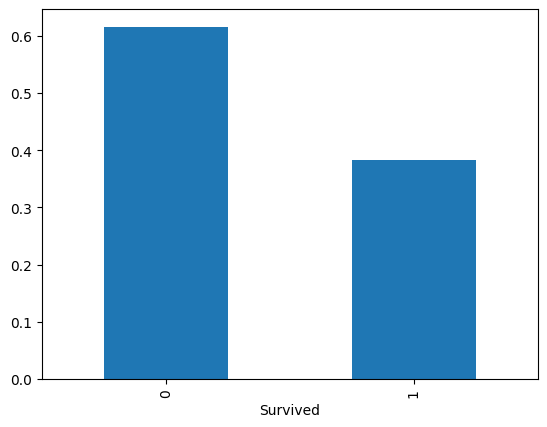

In [ ]:
titanic_df['Survived'].value_counts(normalize=True).plot(kind='bar') # Frecuencia relativa - % de clases

Dado que el enfoque del cuaderno es detectar y manejar valores faltantes. Veamos ahora un proceso paso a paso para gestionar los valores faltantes en un conjunto de datos.

---
## 🎯 Detección de valores faltantes
---


### 🥇 Método de detección

Podemos identificar diferentes métodos, como `isnull()` y `isna()`.

In [ ]:
titanic_df.isnull() # Indicar donde hay valores faltantes, True si falta el valor, False en caso contrario.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


`pandas.DataFrame.any()` es un método que devuelve si algún elemento es verdadero, posiblemente sobre un eje.

In [ ]:
titanic_df.isnull().any(axis=1) # Indicar filas con algún valor faltante

,0
0,True
1,False
2,True
3,False
4,True
...,...
886,True
887,False
888,True
889,False


In [ ]:
titanic_df[titanic_df.isnull().any(axis=1)] # Filas con algun valor faltante

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [ ]:
titanic_df.isnull().any(axis=0) # Indicar columnas con algún valor faltante

,0
PassengerId,False
Survived,False
Pclass,False
Name,False
Sex,False
Age,True
SibSp,False
Parch,False
Ticket,False
Fare,False


Tener en cuenta que los valores True indican los valores que son NaN. Alternativamente, también se puede usar el método `notnull()` para hacer lo mismo. La única diferencia sería que la función indicará True para los valores que no sean nulos.

Podemos usar el método `sum()` para contar la cantidad de valores NaN en el DataFrame.

In [ ]:
titanic_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


El hecho de que `True` sea 1 y `False` sea 0 es la lógica principal para la suma. Los resultados anteriores muestran que 177 valores no fueron informados para `Age`, 687 para `Cabin`y 2 para `Embarked`.

In [ ]:
titanic_df.isna() # Otra forma de detectar Nan

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
def tabla_valores_faltantes(df):
  """
    Genera una tabla con el número y porcentaje de valores faltantes por columna en un DataFrame.

    Parámetros:
    df (pd.DataFrame): DataFrame de entrada.

    Retorna:
    pd.DataFrame: Tabla con columnas que tienen valores faltantes, indicando el número y porcentaje de valores faltantes.
  """
  faltantes_suma = df.isnull().sum() # total de valores faltantes
  faltantes_porc = 100 * (faltantes_suma / len(df)) # porcentaje de valores faltantes
  faltantes_df = pd.concat([faltantes_suma, faltantes_porc], axis=1) # tabla de resultados
  faltantes_df = faltantes_df.rename( # renombramos columnas
        columns = {0 : 'Valores faltantes', 1 : '% del total de valores'}, )

  faltantes_df = faltantes_df[ # ordenar
            faltantes_df.iloc[:,1] != 0].sort_values(
        '% del total de valores', ascending=False).round(1)
  print ("El Dataframe tiene " + str(df.shape[1]) + " columnas.\n"
            "Hay " + str(faltantes_df.shape[0]) +
              " Columnas que tienen valores faltantes.")

  return faltantes_df

In [ ]:
tabla_valores_faltantes(titanic_df) # Llamar función para detectar valores faltantes

El Dataframe tiene 12 columnas.
Hay 3 Columnas que tienen valores faltantes.


,Valores faltantes,% del total de valores
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


---
### 🥇 Detección visual mediante Missingno
---

Para analizar gráficamente la falta de datos, vamos a utilizar una biblioteca llamada [Missingno](https://github.com/ResidentMario/missingno).

Para utilizar esta biblioteca, tenemos que importarla de la siguiente manera:


In [ ]:
import missingno as msno # instalar e importar missingno

## Visualización simple de nulidad

El método bar() permite identificar la cantidad de valores no nulos para cada una de las diferentes características o variables. Las barras muestran el número de valores que no faltan y su valor se indica al principio.

<Axes: >

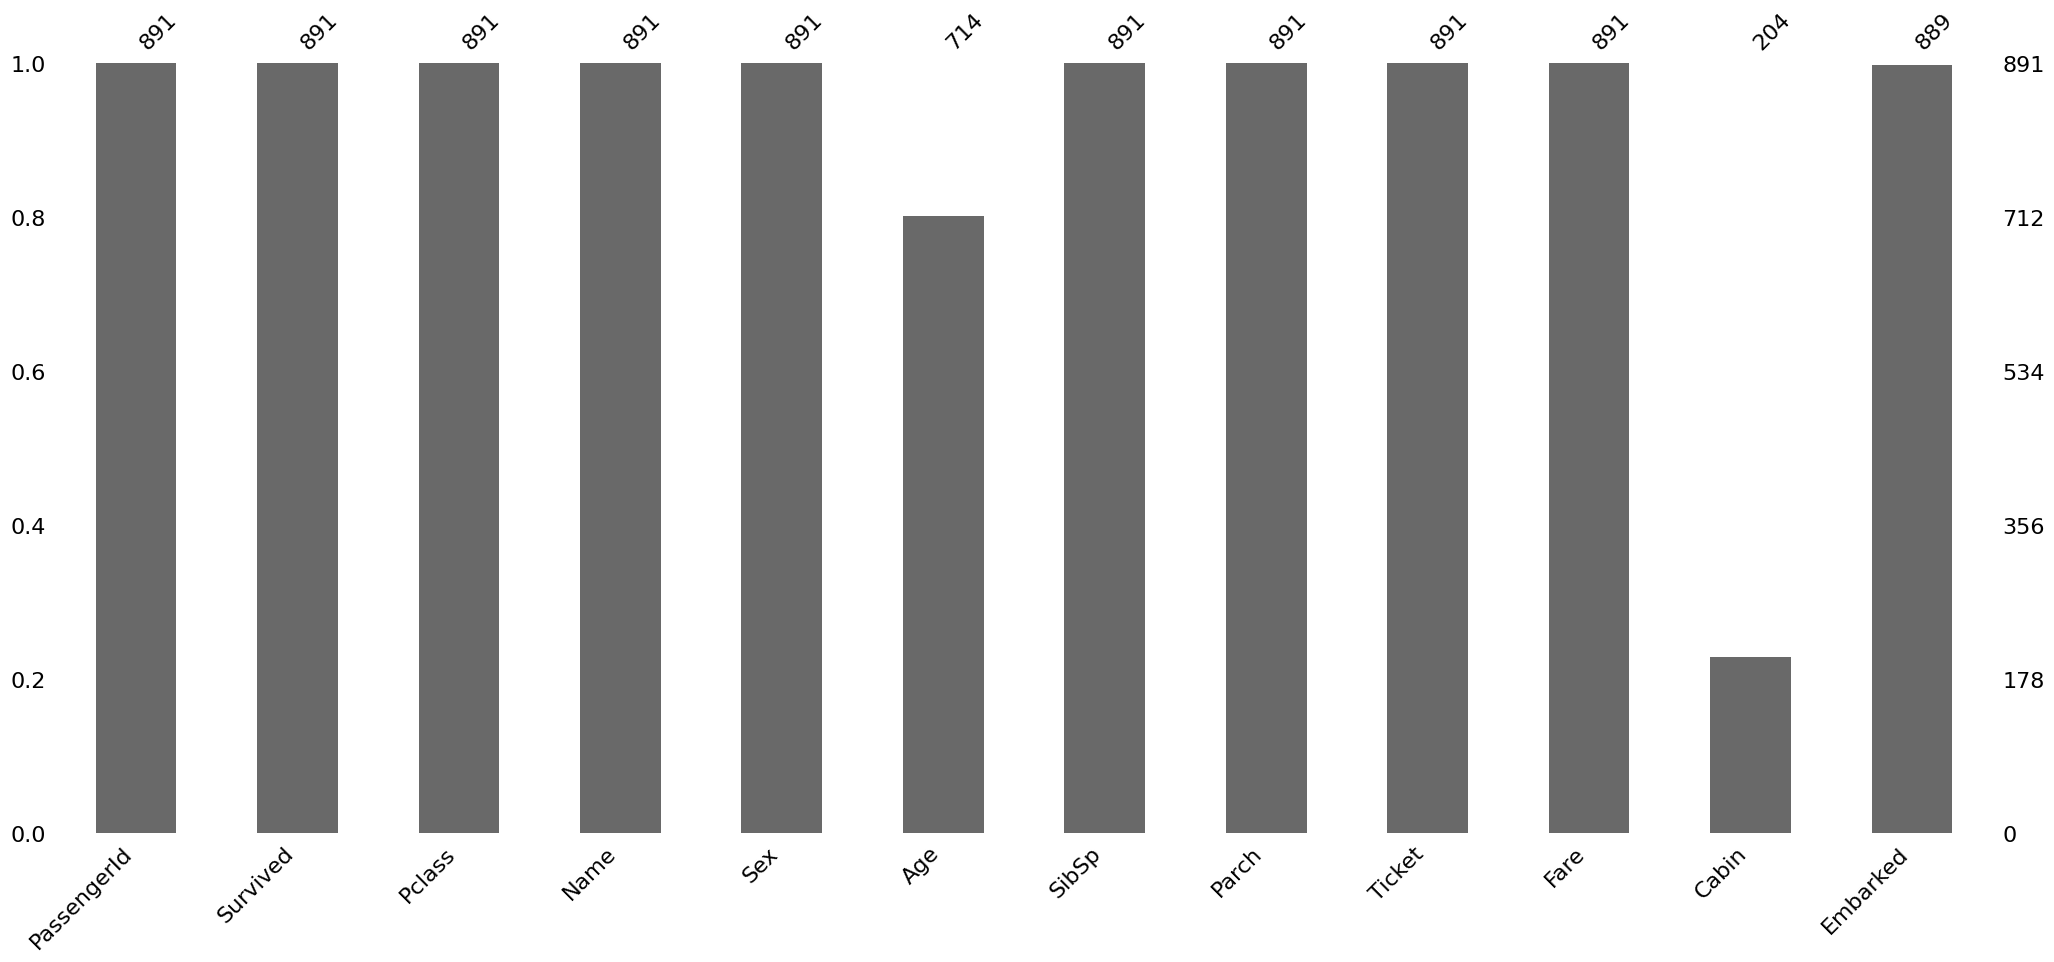

In [ ]:
msno.bar(titanic_df) # Cantidad de valores faltantes por columna

El gráfico de barras ofrece una rápida visión gráfica de la completitud del conjunto de datos.
En el ejemplo, podemos validar nuevamente  que las variables con valores faltantes son `Age`(714 de 891), `Cabin`( 204 de 891) `Embarked` (889 de 891).

Sería conveniente determinar el patrón de los datos que faltan.

#### Visualización de patrón

>La matriz de nulidad [msno.matrix](https://github.com/ResidentMario/missingno#matrix) es una visualización de datos que permite distinguir rápidamente patrones visuales en la completitud de los datos.

<Axes: >

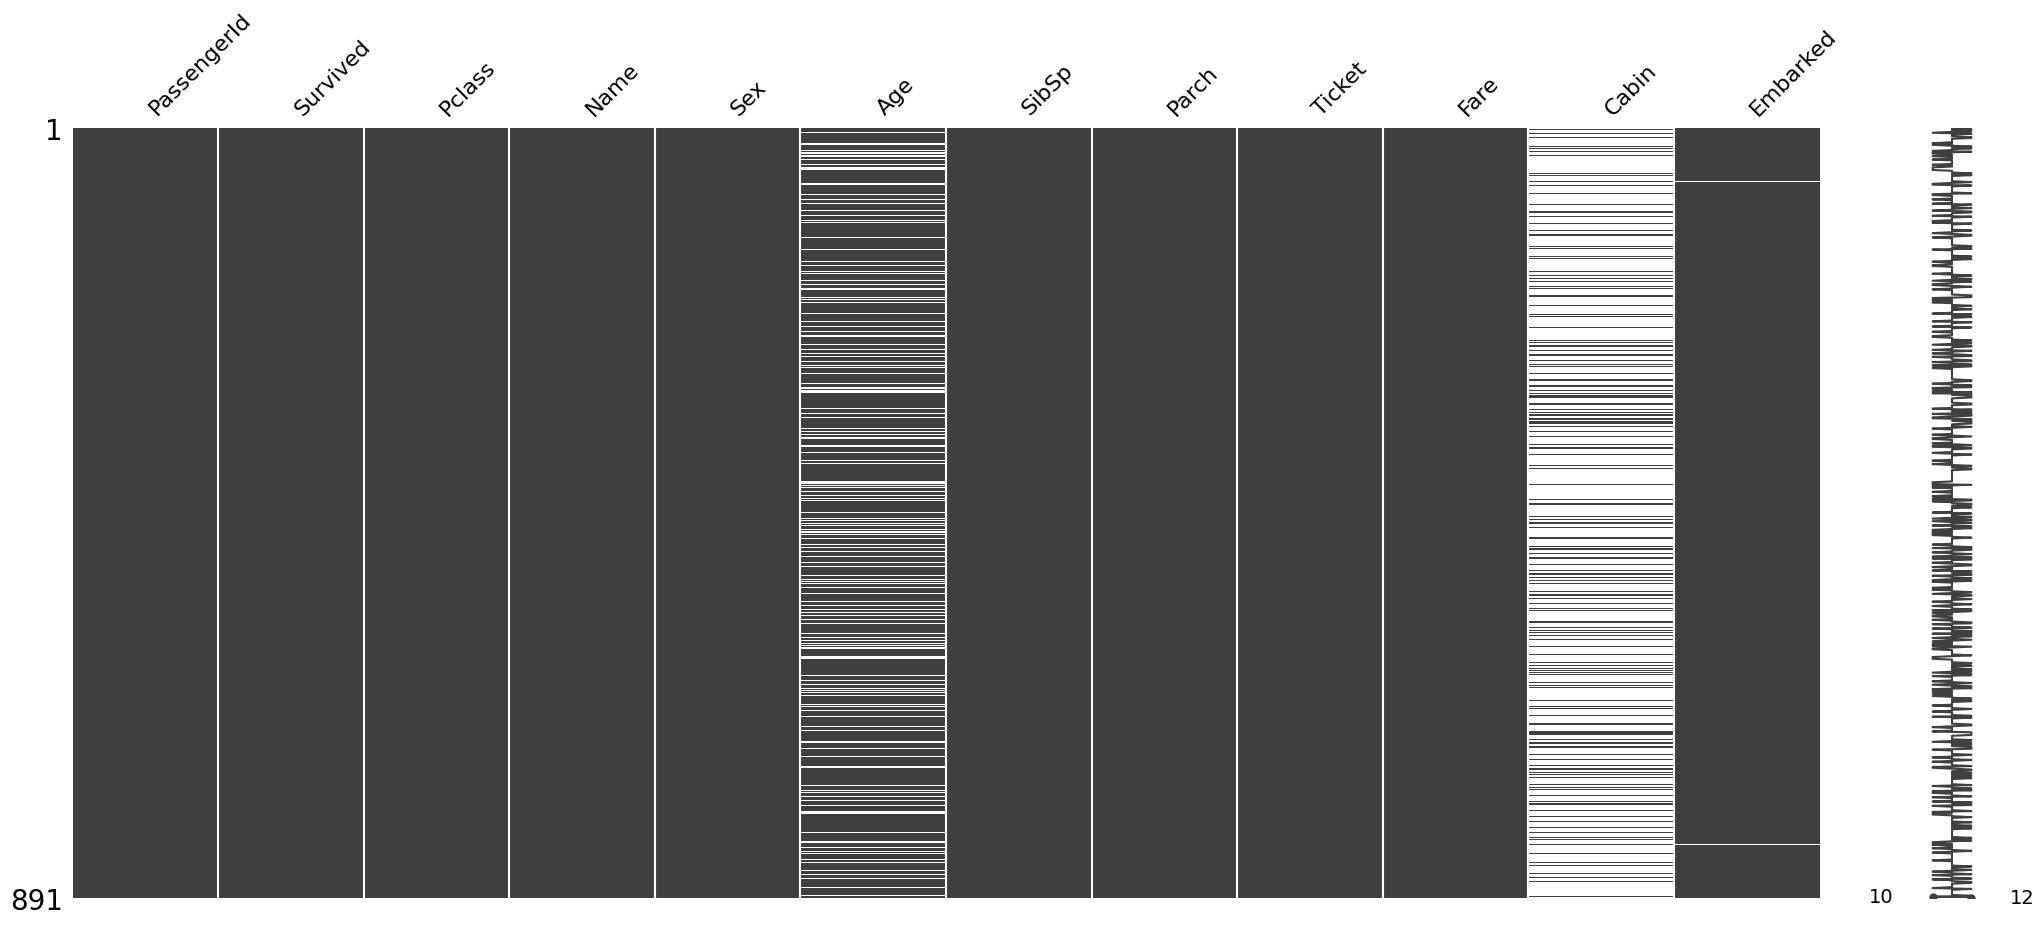

In [ ]:
msno.matrix(titanic_df)

<Axes: >

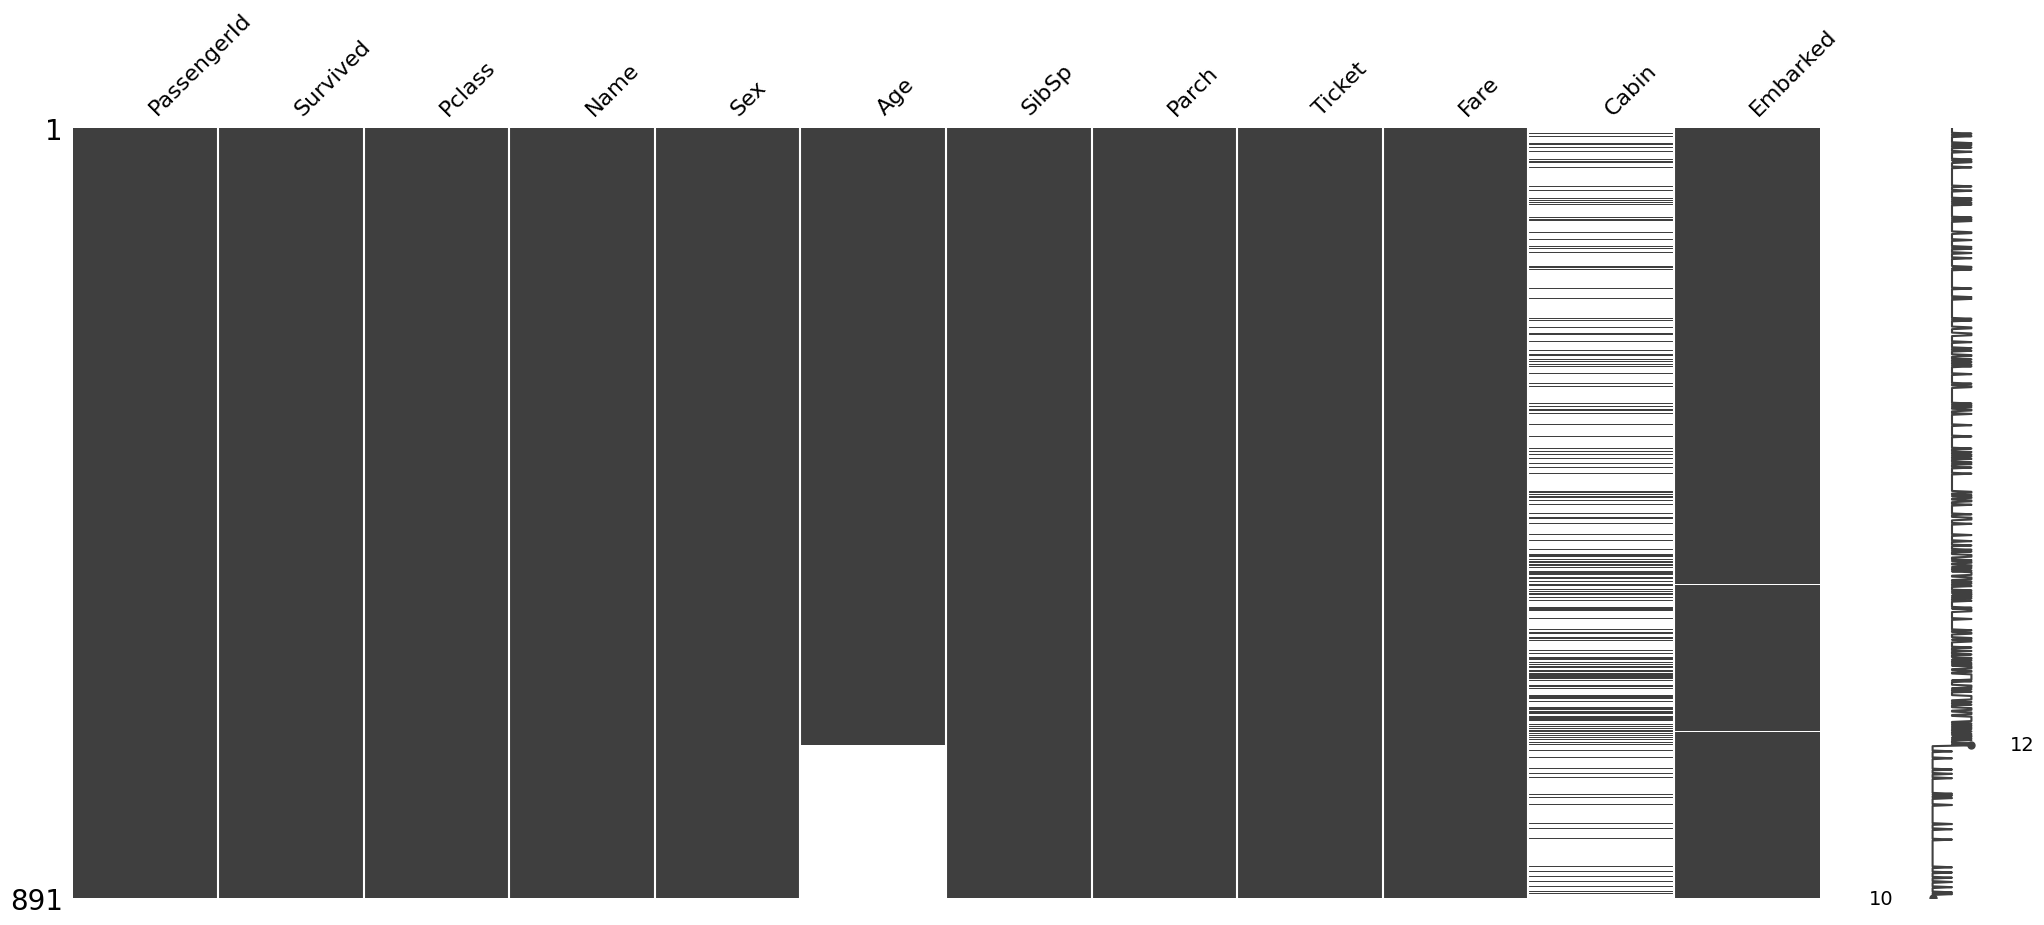

In [ ]:
msno.matrix(titanic_df.sort_values('Age')) # Ordenar el dataframe por Age

<Axes: >

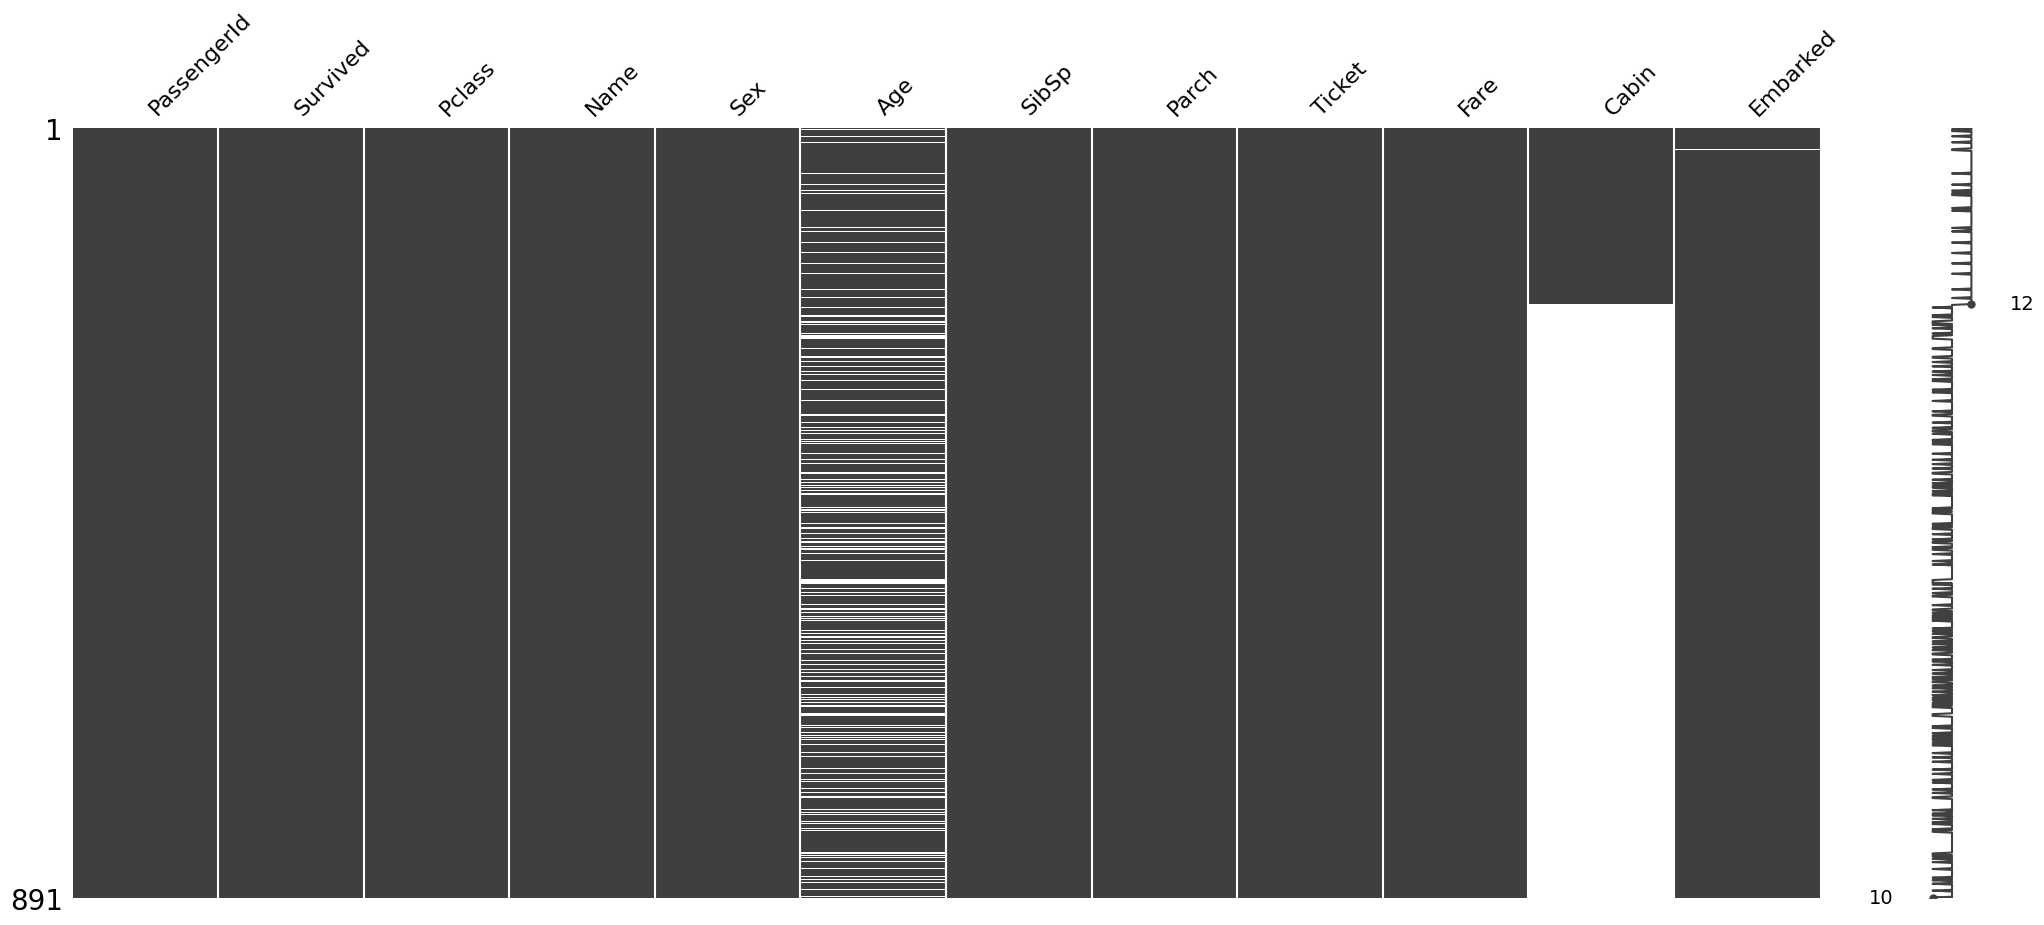

In [ ]:
msno.matrix(titanic_df.sort_values('Cabin')) # Ordenar el dataframe por Cabin

El gráfico de una columna presenta líneas (registros) en blanco cuando faltan valores.

Por ejemplo, en la columna `Embarked` sólo faltan dos datos, de ahí las dos líneas blancas.

**Heatmap (correlación)**

La existencia de correlación entre la presencia y ausencia de datos faltantes en determinadas variables es una muestra de la falta de aleatoriedad del mecanismo de perdida.

<Axes: >

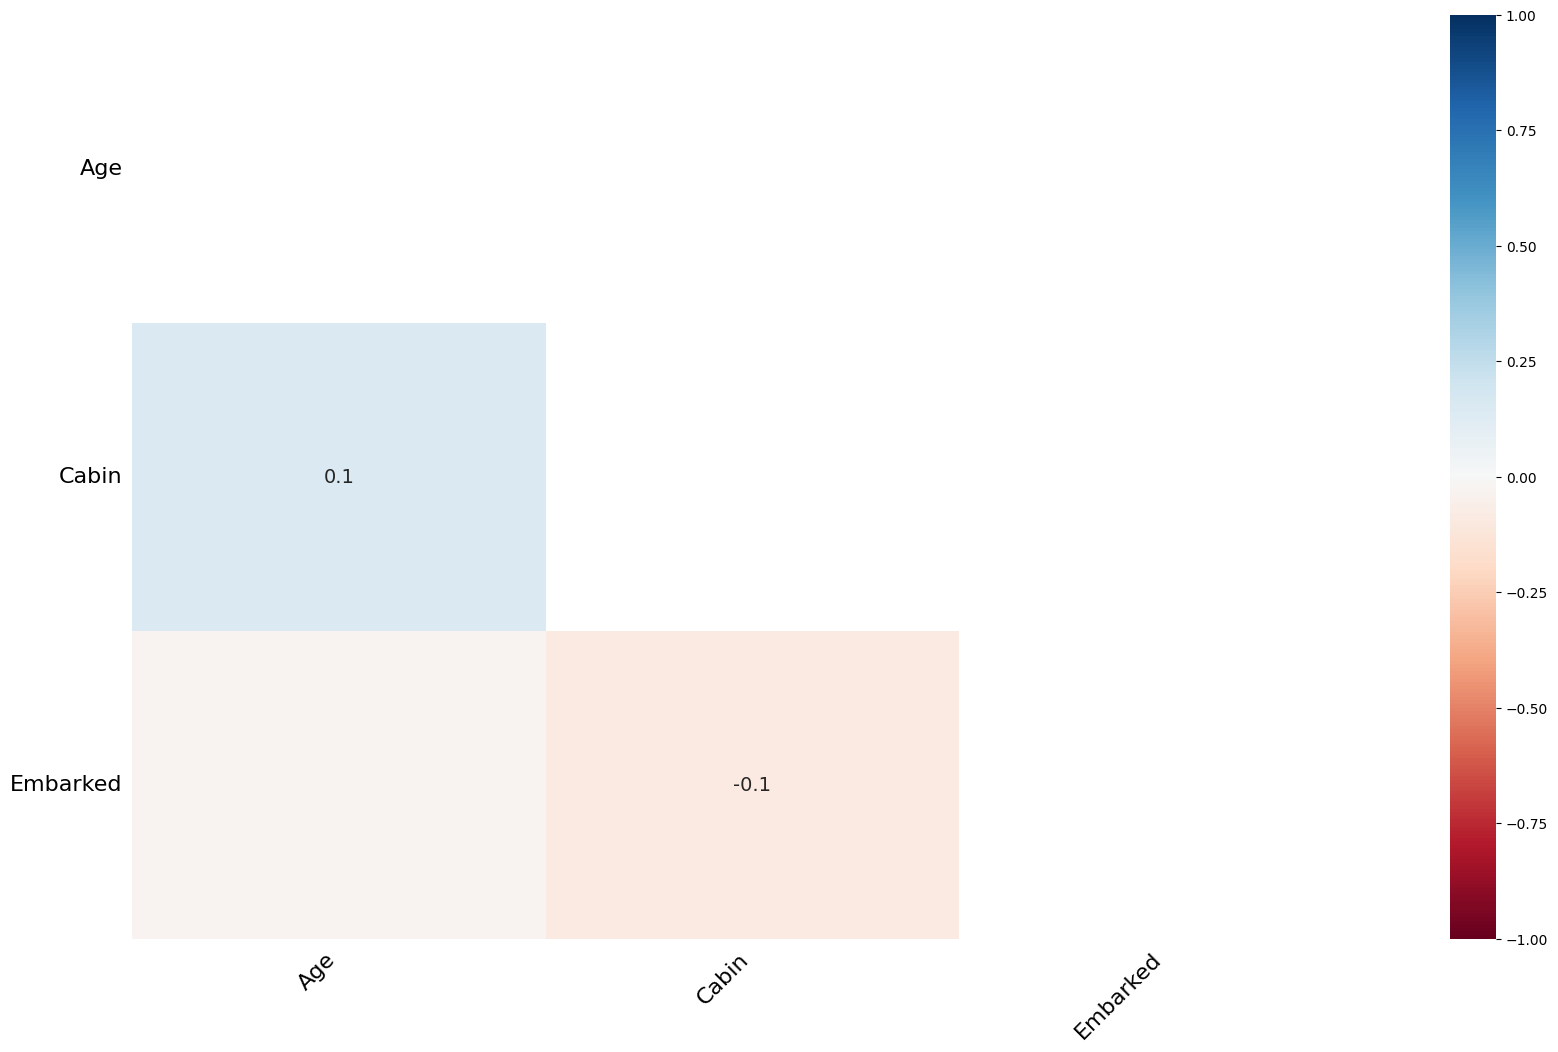

In [ ]:
msno.heatmap(titanic_df)


La correlación toma valores entre -1 y 1.

* -1 - Correlacion negativa exacta implica que si el valor de una variable está presente, en la otra esta ausente.

* 0 - Falta de correlacion implica que no se puede ver una relación lineal.

* 1 - Correlacion positva exacta implica que si una variable tiene valor, en la otra definitivamente va a tomar valor también.

En el ejemplo, podemos ver que no se observa correlación.

📝 **Ejercicio**

Sea el siguiente conjunto de datos almacenado en el DataFrame `estudiantes_df`.

In [ ]:
import pandas as pd
import numpy as np

est_d = {
  'Nombre': ['Lucas','Marcela','Fede','Sol','Sol'],
  'Edad': [np.nan, 26, 37, 40, None],
  'GradoAcademico': ['Bachiller','Licenciado','Magister','Doctorado','Licenciado']
}

# Crear DataFrame
estudiantes_df = pd.DataFrame(est_d)

* Mostrar el DataFrame original.
* Contar los valores faltantes por columna.
* Mostrar las filas con al menos un valor faltante.

**Haz doble click para ver la respuesta**
<!--
# 1. Mostrar el DataFrame original
estudiantes_df
# 2. Contar los valores faltantes por columna
estudiantes_df.isnull().sum()
# 3. Mostrar las filas con al menos un valor faltante
estudiantes_df[estudiantes_df.isnull().any(axis=1)]
-->

---
## 🎯 Tratamiento de valores faltantes: métodos de Imputación
---

Una vez identificados los patrones de los valores que faltan, es importante tratarlos.
Pero antes recordemos:

In [ ]:
titanic_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
titanic_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


* Age = 29.699118 (media)
* Cabin = B96 B98 (moda)
* Embarked = S (moda)

### 🥇 Eliminar datos faltantes

Un camino para gestionar los valores faltantes es eliminar las observaciones (filas) o variables (columnas) que contienen ausencia de datos.

Es una estrategia rápida y sencilla, es más adecuada cuando el porcentaje de datos faltantes es bajo a nivel de observaciones y estos aparecen en lugares aleatorios o variables con un alta cantidad de valores faltantes, en la práctica se considera alto si hablamos de un 80% de valores faltantes.

Pandas ofrece el método `df.dropna()`.

El método dropna() presenta una configuración por defecto como *axis* = 0, y *how* = 'any' que significa eliminar filas cuando hay al menos un valor NaN. Estos argumentos son importantes si se desea eliminar filas o columnas con algunos o todos valores NaN.


##### Eliminar filas

Eliminar filas con valores faltantes, algunos o todos.

In [ ]:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html

titanic_dropna_fila_df = titanic_df.copy() # Copiar dataframe
print("Cantidad de datos sin eliminación:",titanic_dropna_fila_df.shape)


titanic_dropna_fila_df.dropna(inplace=True) # Se considera axis = 0 y how = 'any'(por defecto) e inplace= True para modificar el DataFrame en lugar de crear uno nuevo.
print("Cantidad de datos con eliminación por fila (con algún valor NaN):",titanic_dropna_fila_df.shape)

Cantidad de datos sin eliminación: (891, 12)
Cantidad de datos con eliminación por fila (con algún valor NaN): (183, 12)


In [ ]:
titanic_dropna_fila_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,183.0,NaN,NaN,NaN,455.36612,247.052476,2.0,263.5,457.0,676.0,890.0
Survived,183.0,NaN,NaN,NaN,0.672131,0.470725,0.0,0.0,1.0,1.0,1.0
Pclass,183.0,NaN,NaN,NaN,1.191257,0.515187,1.0,1.0,1.0,1.0,3.0
Name,183,183,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,183,2,male,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,183.0,NaN,NaN,NaN,35.674426,15.643866,0.92,24.0,36.0,47.5,80.0
SibSp,183.0,NaN,NaN,NaN,0.464481,0.644159,0.0,0.0,0.0,1.0,3.0
Parch,183.0,NaN,NaN,NaN,0.47541,0.754617,0.0,0.0,0.0,1.0,4.0
Ticket,183,127,19950,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,183.0,NaN,NaN,NaN,78.682469,76.347843,0.0,29.7,57.0,90.0,512.3292


Para el ejemplo, la eliminación de filas con valores faltantes, ha dado lugar a que el conjunto de datos se redujera a más de la mitad y que cambiarán las propiedades estadísticas. Ejemplo:
* Age = 29.699118 (media) vs 	35.674426 (media)
* Cabin = B96 B98 (moda) vs G6 (moda)
* Embarked = S (moda) vs S (moda)




In [ ]:
# Eliminar valores de filas para una especifica variable
titanic_dropna_fila_df = titanic_df.copy() # Copiar dataframe
print("Cantidad de datos sin eliminación:", titanic_dropna_fila_df.shape)

titanic_dropna_fila_df.dropna(subset=['Age'], how='any', inplace=True) # elminar para la columna Age
print("Cantidad de datos con eliminación por fila (con algún valor NaN):",titanic_dropna_fila_df.shape)


Cantidad de datos sin eliminación: (891, 12)
Cantidad de datos con eliminación por fila (con algún valor NaN): (714, 12)


In [ ]:
titanic_dropna_fila_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


##### Eliminar columnas
Eliminar columnas con valores faltantes, algunos o todos.

Si una columna contiene muchos valores faltantes, digamos más del 80%, y la característica no es significativa, es posible que desee eliminar esa característica. Sin embargo, de nuevo, no es recomendable borrar los datos.

In [ ]:
titanic_dropna_columna_df = titanic_df.copy() # Copiar dataframe
print("Cantidad de datos sin eliminación:",titanic_dropna_columna_df.shape)

titanic_dropna_columna_df.dropna(axis=1, inplace=True) # se indica axis=1 para eliminar columna
print("Cantidad de datos con eliminación por columnaN (con algún valor NaN):",titanic_dropna_columna_df.shape)

Cantidad de datos sin eliminación: (891, 12)
Cantidad de datos con eliminación por columnaN (con algún valor NaN): (891, 9)


In [ ]:
titanic_dropna_columna_df = titanic_df.copy()
print("Cantidad de datos sin eliminación:",titanic_dropna_columna_df.shape)

titanic_dropna_columna_df.drop(['Cabin'], axis=1, inplace=True) # Por columna especificada
print("Cantidad de datos con eliminación por columna (con algún valor NaN):",titanic_dropna_columna_df.shape)

Cantidad de datos sin eliminación: (891, 12)
Cantidad de datos con eliminación por columna (con algún valor NaN): (891, 11)


### 🥇Técnicas de imputación para datos no en series temporales
La imputación implica completar los valores faltantes con valores estimados o calculados. Los métodos de imputación comunes incluyen la imputación de media, mediana y moda, o el uso de técnicas más avanzadas.

Pandas ofrece el método `pd.fillna()`. Entre sus argumentos, el principal es *value* que indica el valor que se usará para rellenar los valores vacíos (p. ej., 0). Puede ser una constante, un dict/Series/DataFrame de valores que especifica qué valor usar para cada índice (para una serie) o columna (para un DataFrame). Los valores que no están en el dict/Series/DataFrame no se rellenarán.


#### Técnicas básicas de imputación

  - Imputación con un valor constante
  - Imputación utilizando estadísticos (media, mediana o más frecuente) de cada columna en la que se encuentran los valores que faltan



In [ ]:
titanic_df.loc[titanic_df.isnull().any(axis=1)].head(5) #  Mostrar registros que tengan valores faltantes - nulos


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S


**Imputación con un valor constante**

In [ ]:
titanic_fillna_df = titanic_df.copy() # Copiar
titanic_fillna_df.fillna(0,inplace=True) # Rellenar con 0 los valores faltantes del dataframe.


In [ ]:
titanic_fillna_df.loc[titanic_df.isnull().any(axis=1)].head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,0,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,0,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,0,S
5,6,0,3,"Moran, Mr. James",male,0.0,0,0,330877,8.4583,0,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,0,S


In [ ]:
display(titanic_fillna_df.isnull().sum())

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**Imputación utilizando estadísticos**

La imputación por media rellena los valores faltantes con la media de los valores observados en la variable. Es un método muy sencillo y no introduce sesgo cuando los valores faltantes son completamente aleatorios.

Sin embargo, este método es sensible a los valores atípicos y puede distorsionar la distribución de la variable.

La imputación por mediana es robusta en presencia de valores atípicos y puede ser una buena opción cuando la distribución está sesgada.

In [ ]:
# Estadística para variables con datos faltantes
print("Estadísticas para \n * Age(media):{}\n * Cabin(moda):\n{}\n * Embarked(moda):\n{}" .format(titanic_df['Age'].mean(), titanic_df['Cabin'].mode(), titanic_df['Embarked'].mode()))


Estadísticas para 
 * Age(media):29.69911764705882
 * Cabin(moda):
0        B96 B98
1    C23 C25 C27
2             G6
Name: Cabin, dtype: object
 * Embarked(moda):
0    S
Name: Embarked, dtype: object


In [ ]:
# Diccionario para indicar los valores de relleno para cada variable especificada
valores = { "Age": titanic_df['Age'].mean(),
           "Cabin": titanic_df['Cabin'].mode()[0],
            "Embarked": titanic_df['Embarked'].mode()[0]
            }
valores

{'Age': np.float64(29.69911764705882), 'Cabin': 'B96 B98', 'Embarked': 'S'}

In [ ]:
titanic_fillna_df = titanic_df.copy() # Copiar
display(titanic_fillna_df.loc[titanic_fillna_df.isnull().any(axis=1)].head(5))

titanic_fillna_df.fillna(valores, inplace = True) # fillna con valores a rellnar
display(titanic_fillna_df.loc[titanic_df.isnull().any(axis=1)].head(5))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,B96 B98,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,B96 B98,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,B96 B98,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,B96 B98,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,B96 B98,S


In [ ]:
titanic_fillna_df[['Age','Cabin','Embarked']].describe(include='all')

,Age,Cabin,Embarked
count,891.000000,891,891
unique,NaN,147,3
top,NaN,B96 B98,S
freq,NaN,691,646
mean,29.699118,NaN,NaN
std,13.002015,NaN,NaN
min,0.420000,NaN,NaN
25%,22.000000,NaN,NaN
50%,29.699118,NaN,NaN
75%,35.000000,NaN,NaN


Imputar por media

In [ ]:

titanic_fillna_df = titanic_df.copy() # Copiar
print('Antes de imputar Age')
display(titanic_fillna_df.loc[titanic_fillna_df['Age'].isnull(),['Age','Cabin','Embarked']].head(5))

media = titanic_fillna_df['Age'].mean() # Media
titanic_fillna_df['Age'] = titanic_fillna_df['Age'].fillna(media)

print('Después de imputar Age por media')
display(titanic_fillna_df.loc[titanic_df['Age'].isnull(),['Age','Cabin','Embarked']].head(5))

Antes de imputar Age


,Age,Cabin,Embarked
5,NaN,NaN,Q
17,NaN,NaN,S
19,NaN,NaN,C
26,NaN,NaN,C
28,NaN,NaN,Q


Después de imputar Age por media


,Age,Cabin,Embarked
5,29.699118,NaN,Q
17,29.699118,NaN,S
19,29.699118,NaN,C
26,29.699118,NaN,C
28,29.699118,NaN,Q


**`SimpleImputer` de sklearn**

Imputador univariante para completar valores faltantes con estrategias sencillas.

Reemplaza los valores faltantes utilizando un estadístico descriptivo (p. ej., media, mediana o más frecuente) en cada columna o utilizando un valor constante.

La estrategia de imputación:
* Si es “media”, entonces reemplaza los valores faltantes usando la media a lo largo de cada columna. Solo se puede usar con datos numéricos.
* Si es “mediana”, entonces reemplaza los valores faltantes usando la mediana a lo largo de cada columna. Solo se puede usar con datos numéricos.
* Si es “más_frecuente”, entonces reemplaza los valores faltantes usando el valor más frecuente a lo largo de cada columna. Se puede usar con cadenas o datos numéricos. Si hay más de un valor de este tipo, solo se devuelve el más pequeño.
* Si es “constante”, entonces reemplaza los valores faltantes con "missing_value". Se puede usar con cadenas o datos numéricos.

Para más información, click en [SimpleImputer en documentación oficial](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html)

In [ ]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
from sklearn.impute import SimpleImputer # importar libreria

In [ ]:
titanic_df_constant = titanic_df.copy() # Copiar Dataframe

In [ ]:
constant_imputer = SimpleImputer(strategy='constant') # Crear objeto de imputación
constant_imputer

SimpleImputer(strategy='constant')

el método fit_transform() del objeto simpleImputer aprendé de los datos y luego los transforma. Devuelve una matriz ndarray de la forma (n_filas, n_columnas nuevas)

In [ ]:
matriz_imputada = constant_imputer.fit_transform(titanic_df_constant) # Entrenar y aprender
matriz_imputada

array([[1, 0, 3, ..., 7.25, 'missing_value', 'S'],
       [2, 1, 1, ..., 71.2833, 'C85', 'C'],
       [3, 1, 3, ..., 7.925, 'missing_value', 'S'],
       ...,
       [889, 0, 3, ..., 23.45, 'missing_value', 'S'],
       [890, 1, 1, ..., 30.0, 'C148', 'C'],
       [891, 0, 3, ..., 7.75, 'missing_value', 'Q']], dtype=object)

In [ ]:
titanic_df_constant.iloc[:,:]  = matriz_imputada # Asigno la matriz

<ipython-input-120-c8da2430bea6>:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[22.0, 38.0, 26.0, 35.0, 35.0, 'missing_value', 54.0, 2.0, 27.0, 14.0, 4.0, 58.0, 20.0, 39.0, 14.0, 55.0, 2.0, 'missing_value', 31.0, 'missing_value', 35.0, 34.0, 15.0, 28.0, 8.0, 38.0, 'missing_value', 19.0, 'missing_value', 'missing_value', 40.0, 'missing_value', 'missing_value', 66.0, 28.0, 42.0, 'missing_value', 21.0, 18.0, 14.0, 40.0, 27.0, 'missing_value', 3.0, 19.0, 'missing_value', 'missing_value', 'missing_value', 'missing_value', 18.0, 7.0, 21.0, 49.0, 29.0, 65.0, 'missing_value', 21.0, 28.5, 5.0, 11.0, 22.0, 38.0, 45.0, 4.0, 'missing_value', 'missing_value', 29.0, 19.0, 17.0, 26.0, 32.0, 16.0, 21.0, 26.0, 32.0, 25.0, 'missing_value', 'missing_value', 0.83, 30.0, 22.0, 29.0, 'missing_value', 28.0, 17.0, 33.0, 16.0, 'missing_value', 23.0, 24.0, 29.0, 20.0, 46.0, 26.0, 59.0, 'missing_value', 71.0, 23.0, 34.0, 34.0, 28.0, 'miss

In [ ]:
display(titanic_df_constant.loc[titanic_df.isnull().any(axis=1)].head(5)) # Reemplaza por "missing_value"

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,missing_value,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,missing_value,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,missing_value,S
5,6,0,3,"Moran, Mr. James",male,missing_value,0,0,330877,8.4583,missing_value,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,missing_value,S


Otra manera crear un nuevo Dataframe con la matriz

In [ ]:
titanic_df_constant = pd.DataFrame(matriz_imputada, columns = titanic_df_constant.columns)


En el ejemplo dado, no se ha especificado un valor constante específico, por lo que el imputador utilizará el valor por defecto, que es 'missing_value'.

Si deseas especificar un valor constante diferente, puedes hacerlo proporcionando el parámetro `fill_value` al crear la instancia de SimpleImputer. Veamos un ejemplo aplicado a una columna:

In [ ]:
titanic_df_constant = titanic_df.copy() # copiar

contant_imputer = SimpleImputer(strategy='constant', fill_value=-999) # Crear objeto

titanic_df_constant['Age'] = contant_imputer.fit_transform(titanic_df_constant[['Age']])

display(titanic_df_constant.isnull().sum())


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Imputar por media através de simpleImputer

In [ ]:
titanic_df_constant = titanic_df.copy() # copiar

mean_imputer = SimpleImputer(missing_values=np.nan,strategy='mean') # Crear objeto

titanic_df_constant['Age'] = mean_imputer.fit_transform(titanic_df_constant[['Age']])

display(titanic_df_constant.isnull().sum())


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Existen diversar librerias trabajar con la limpieza de datos y la automatización. Usando [sklearn.pipeline import Pipeline](https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_pipeline_display.html#sphx-glr-auto-examples-miscellaneous-plot-pipeline-display-py) ya se puede empezar.

Más ejemplos: [ver](https://stackoverflow.com/questions/57059571/how-to-use-simpleimputer-class-to-impute-missing-values-in-different-columns-wit)

📝 **Ejercicio**

Sea el siguiente conjunto de datos almacenado en el DataFrame `estudiantes_df`.

In [ ]:
import pandas as pd
import numpy as np

est_d = {
  'Nombre': ['Lucas','Marcela','Fede','Sol','Sol'],
  'Edad': [np.nan, 26, 37, 40, None],
  'GradoAcademico': ['Bachiller','Licenciado','Magister','Doctorado','Licenciado']
}

# Crear DataFrame
estudiantes_df = pd.DataFrame(est_d)

* Usar SimpleImputer con estrategia='mean' para imputar los valores faltantes de la columna 'edad'
* Mostrar el resultado como DataFrame

**Haz doble click para ver la respuesta**
<!--
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(missing_values=np.nan,strategy='mean') # Crear objeto

estudiantes_df['Edad'] = mean_imputer.fit_transform(estudiantes_df[['Edad']])

display(estudiantes_df.isnull().sum())
display(estudiantes_df)
-->

### 🥇 Técnicas de imputación para problemas de series temporales

Veamos ahora las formas de imputar datos en un problema típico de series temporales. Tratar los valores perdidos en un problema de series temporales es un poco diferente. El método `fillna()` se utiliza para imputar valores perdidos en este tipo de problemas.

* Técnicas básicas de imputación
  - ffill' o 'pad' - Sustituir NaN s por el último valor observado
  - bfill' o 'backfill' - Sustituir los valores NaN por el siguiente valor observado
  - Método de interpolación lineal

  

#### Conjunto de datos de series temporales

El conjunto de datos se llama [Air Quality Data in India (2015 - 2020)](https://www.kaggle.com/rohanrao/air-quality-data-in-india) y contiene datos sobre la calidad del aire e ICA (Índice de Calidad del Aire) a nivel horario y diario de varias estaciones de múltiples ciudades de la India. El conjunto de datos tiene muchos valores perdidos y es un problema clásico de series temporales.

In [ ]:
# Leer los datos
url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'city_day.csv'

ruta_archivo = url_base + nombre_archivo #

city_day = pd.read_csv(ruta_archivo,parse_dates=True,index_col='Date')

city_day.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
Date,,,,,,,,,,,,,,,
2015-01-01,Ahmedabad,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
2015-01-02,Ahmedabad,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2015-01-03,Ahmedabad,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
2015-01-04,Ahmedabad,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
2015-01-05,Ahmedabad,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
city_day.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 29531 entries, 2015-01-01 to 2020-07-01
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   PM2.5       24933 non-null  float64
 2   PM10        18391 non-null  float64
 3   NO          25949 non-null  float64
 4   NO2         25946 non-null  float64
 5   NOx         25346 non-null  float64
 6   NH3         19203 non-null  float64
 7   CO          27472 non-null  float64
 8   SO2         25677 non-null  float64
 9   O3          25509 non-null  float64
 10  Benzene     23908 non-null  float64
 11  Toluene     21490 non-null  float64
 12  Xylene      11422 non-null  float64
 13  AQI         24850 non-null  float64
 14  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(2)
memory usage: 3.6+ MB


En este cuaderno, vamos a mantener nuestro enfoque en los valores que faltan solamente. Como es evidente, city_day dataframe consiste en datos diarios del nivel de contaminación de algunas de las ciudades más importantes de la India.



In [ ]:
#Missing Values
city_day_missing = tabla_valores_faltantes(city_day)

city_day_missing

El Dataframe tiene 15 columnas.
Hay 14 Columnas que tienen valores faltantes.


,Valores faltantes,% del total de valores
Xylene,18109,61.3
PM10,11140,37.7
NH3,10328,35.0
Toluene,8041,27.2
Benzene,5623,19.0
AQI,4681,15.9
AQI_Bucket,4681,15.9
PM2.5,4598,15.6
NOx,4185,14.2
O3,4022,13.6


Faltan muchos valores y en algunas columnas, como Xileno y PM10, faltan más del 50% de los valores. Veamos ahora cómo podemos imputar estos valores que faltan.



In [ ]:
city_day['Xylene'][50:70]

,Xylene
Date,
2015-02-20,7.48
2015-02-21,15.44
2015-02-22,8.47
2015-02-23,28.46
2015-02-24,6.05
2015-02-25,0.81
2015-02-26,NaN
2015-02-27,NaN
2015-02-28,NaN


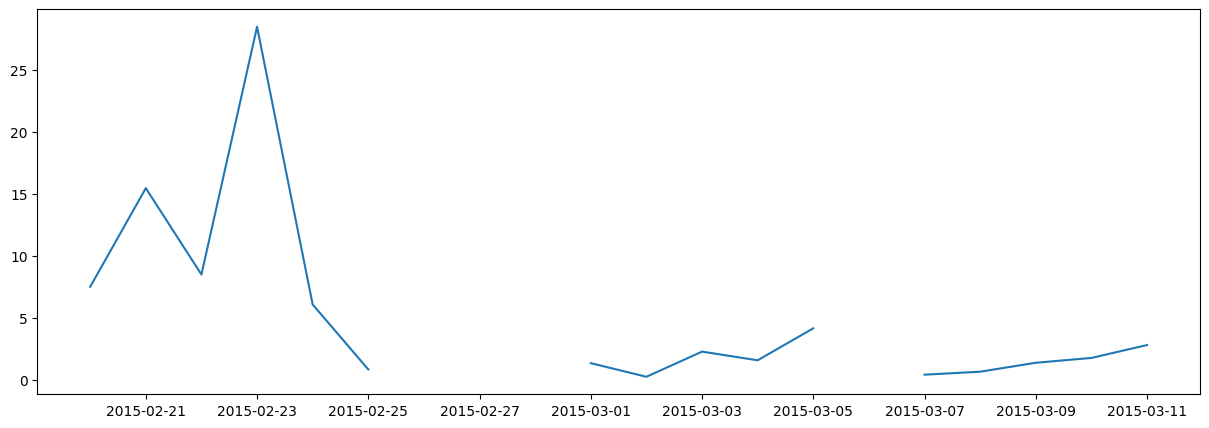

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot( city_day['Xylene'][50:70])
plt.show()



Arriba vemos que faltan 3 valores en la columna Xileno, en ese rango.

#### Imputación utilizando ffill

In [ ]:
city_day1 = city_day.copy(deep=True) # Copiar

city_day1.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
Date,,,,,,,,,,,,,,,
2015-01-01,Ahmedabad,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
2015-01-02,Ahmedabad,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2015-01-03,Ahmedabad,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
2015-01-04,Ahmedabad,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
2015-01-05,Ahmedabad,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
city_day1.fillna(method='ffill',inplace=True)
city_day1['Xylene'][50:70]

<ipython-input-132-135395c69cf9>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  city_day1.fillna(method='ffill',inplace=True)


,Xylene
Date,
2015-02-20,7.48
2015-02-21,15.44
2015-02-22,8.47
2015-02-23,28.46
2015-02-24,6.05
2015-02-25,0.81
2015-02-26,0.81
2015-02-27,0.81
2015-02-28,0.81


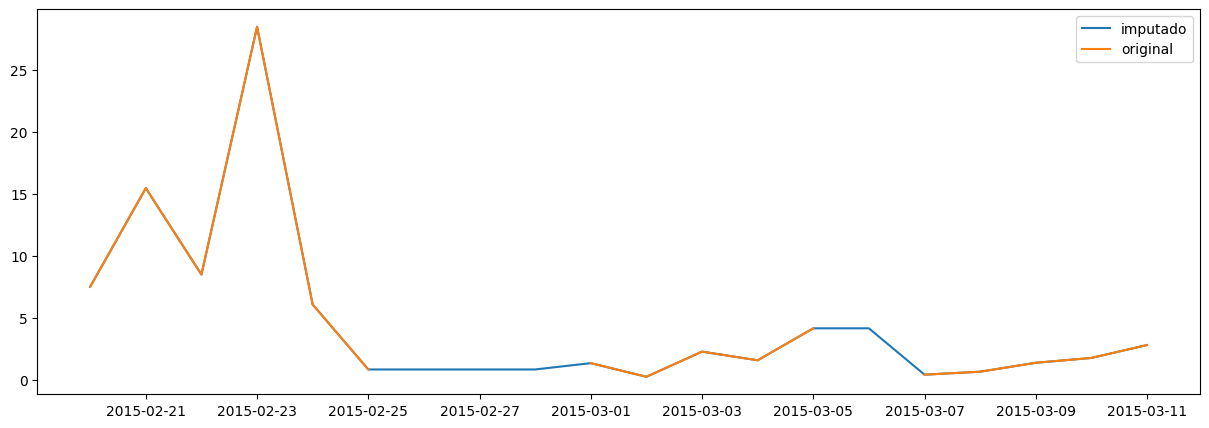

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(city_day1['Xylene'][50:70], label = "imputado")
plt.plot(city_day['Xylene'][50:70], label = "original")
plt.legend()
plt.show()

Podemos ver que todos los valores que faltan se han rellenado con los últimos valores observados.

#### Imputación utilizando bfill

In [ ]:
# Imputing AQI value
city_day1 = city_day.copy()
city_day1['AQI'][50:70]

,AQI
Date,
2015-02-20,588.0
2015-02-21,1141.0
2015-02-22,669.0
2015-02-23,1247.0
2015-02-24,411.0
2015-02-25,292.0
2015-02-26,NaN
2015-02-27,NaN
2015-02-28,NaN


In [ ]:
city_day1.fillna(method='bfill',inplace=True)
city_day1['AQI'][50:70]

<ipython-input-135-d38f96a8e660>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  city_day1.fillna(method='bfill',inplace=True)


,AQI
Date,
2015-02-20,588.0
2015-02-21,1141.0
2015-02-22,669.0
2015-02-23,1247.0
2015-02-24,411.0
2015-02-25,292.0
2015-02-26,189.0
2015-02-27,189.0
2015-02-28,189.0


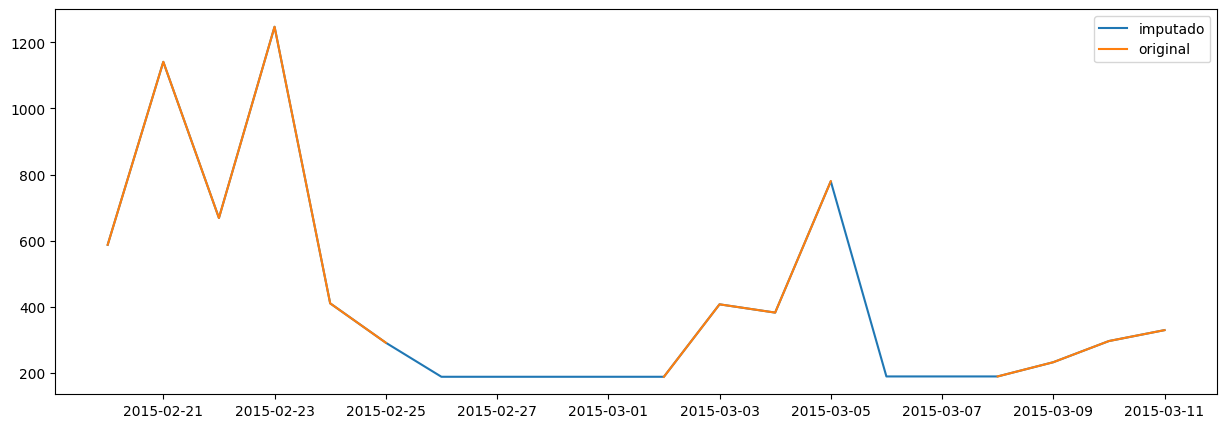

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(city_day1['AQI'][50:70], label = "imputado")
plt.plot(city_day['AQI'][50:70], label = "original")
plt.legend()
plt.show()

Podemos ver que todos los valores ausentes se han rellenado con los siguientes valores observados.

#### Imputación mediante el método de interpolación lineal

Los datos de series temporales varían mucho con el tiempo. Por lo tanto, la imputación mediante el relleno con backfill y forward fill no es la mejor solución posible para abordar el problema. Una alternativa más adecuada sería emplear el método de interpolación, en el que los valores se rellenan con valores crecientes o decrecientes en función de la tendencia.

La [interpolación lineal](https://www.lexjansen.com/nesug/nesug01/ps/ps8026.pdf) es una técnica de imputación que asume una relación lineal entre los valores de los datos, este aprovecha los valores presentes de las variables adyacentes para calcular el valor para un punto ausente.

Consulte la documentación oficial para obtener una lista completa de estrategias de interpolación [aquí](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.interpolate.html)

In [ ]:
city_day1 = city_day.copy()
city_day1['Xylene'][50:70]

,Xylene
Date,
2015-02-20,7.48
2015-02-21,15.44
2015-02-22,8.47
2015-02-23,28.46
2015-02-24,6.05
2015-02-25,0.81
2015-02-26,NaN
2015-02-27,NaN
2015-02-28,NaN


In [ ]:
# Interpolate using the linear method
city_day1.interpolate(limit_direction="both",inplace=True)
city_day1['Xylene'][50:70]

<ipython-input-138-a2caaea23cbc>:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  city_day1.interpolate(limit_direction="both",inplace=True)


,Xylene
Date,
2015-02-20,7.4800
2015-02-21,15.4400
2015-02-22,8.4700
2015-02-23,28.4600
2015-02-24,6.0500
2015-02-25,0.8100
2015-02-26,0.9375
2015-02-27,1.0650
2015-02-28,1.1925


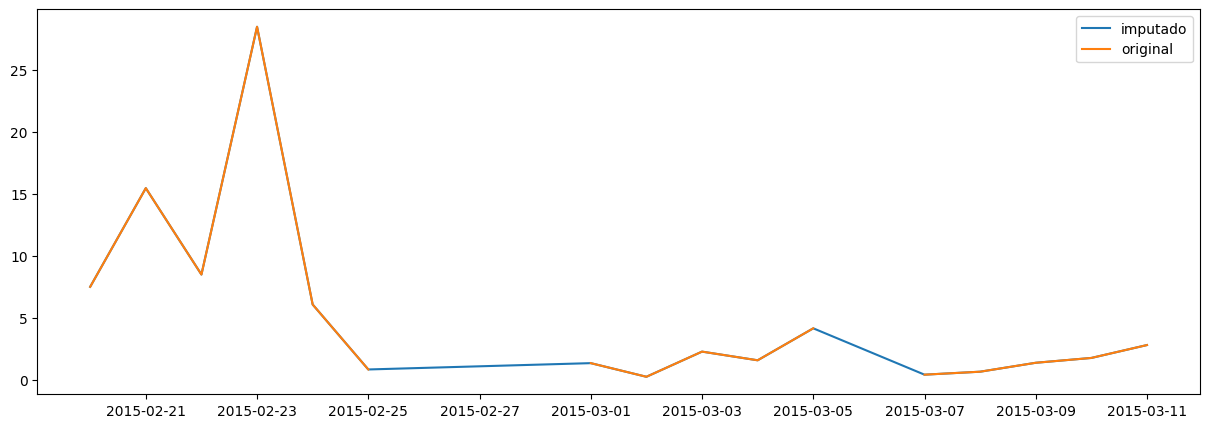

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(city_day1['Xylene'][50:70], label = "imputado")
plt.plot(city_day['Xylene'][50:70], label = "original")
plt.legend()
plt.show()

##  🎯 Técnicas avanzadas de imputación

Las técnicas avanzadas de imputación utilizan algoritmos de aprendizaje automático para imputar los valores que faltan en un conjunto de datos, a diferencia de las técnicas anteriores, en las que utilizamos valores de otras columnas para predecir los valores ausentes. En esta notebook examinaremos las siguientes dos técnicas:

* [Imputación de vecinos más cercanos](https://scikit-learn.org/stable/modules/impute.html#nearest-neighbors-imputation)
* [Multivariate feature imputation](https://scikit-learn.org/stable/modules/impute.html#multivariate-feature-imputation)

La clase [KNNImputer](https://scikit-learn.org/stable/modules/impute.html#multivariate-feature-imputation) proporciona la imputación para rellenar los valores que faltan utilizando el enfoque k-Nearest Neighbors. Cada característica que falta se imputa utilizando los valores de n_vecinos más cercanos que tienen un valor para la característica. Las características de los vecinos se promedian uniformemente o se ponderan en función de la distancia a cada vecino.

K-Nearest Neighbor es un algoritmo muy utilizado para una clasificación simple. El algoritmo utiliza "similitud de características" para predecir los valores de cualquier nuevo punto de datos. Esto significa que al nuevo punto se le asigna un valor en función de su parecido con los puntos del conjunto de entrenamiento. Esto es muy útil para hacer predicciones sobre  valores faltantes al encontrar los k-vecinos más cercanos a la observación con datos perdidos y luego imputarlos en función de los valores no perdidos en el vecindario.

Hay varias librerias que tienen este algoritmo

- <span style="color:FireBrick">**Fancyimpute**</span>

- <span style="color:FireBrick">**impyute**</span>

- <span style="color:FireBrick">**sklearn.impute**</span>

El siguiente codigo tiene un ejemplo del uso de la clase KNNImputer de Sklearn

In [ ]:
# https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html
from sklearn.impute import KNNImputer


city_day_knn = city_day.copy(deep=True)

knn_imputer = KNNImputer(n_neighbors = 3) # , weights="uniform" Crear objeto

city_day_knn['Xylene'] = knn_imputer.fit_transform(city_day_knn[['Xylene']]) # aprender y transformar

In [ ]:
city_day['Xylene'][50:70]

,Xylene
Date,
2015-02-20,7.48
2015-02-21,15.44
2015-02-22,8.47
2015-02-23,28.46
2015-02-24,6.05
2015-02-25,0.81
2015-02-26,NaN
2015-02-27,NaN
2015-02-28,NaN


In [ ]:
city_day_knn['Xylene'][50:70]

,Xylene
Date,
2015-02-20,7.480000
2015-02-21,15.440000
2015-02-22,8.470000
2015-02-23,28.460000
2015-02-24,6.050000
2015-02-25,0.810000
2015-02-26,3.070128
2015-02-27,3.070128
2015-02-28,3.070128


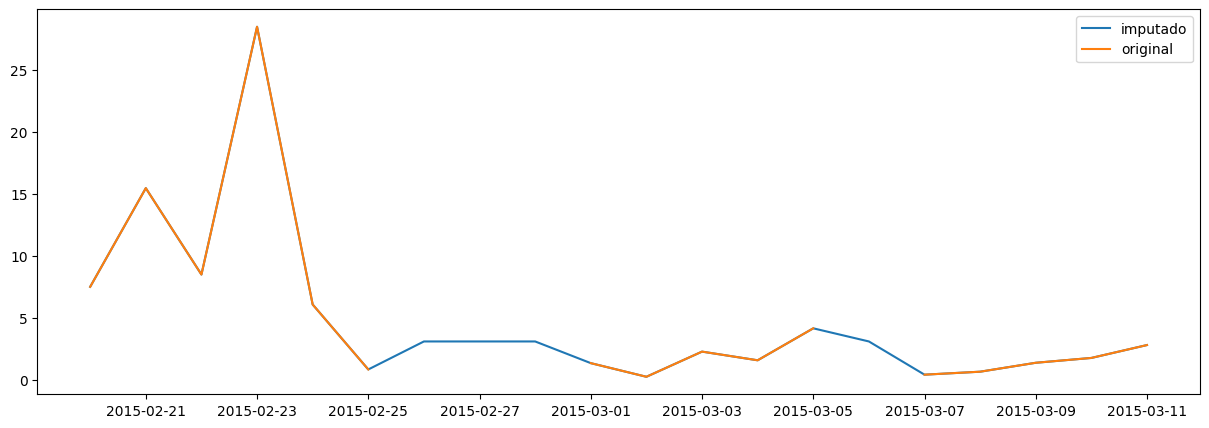

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(city_day_knn['Xylene'][50:70], label = "imputado")
plt.plot(city_day['Xylene'][50:70], label = "original")
plt.legend()
plt.show()

**¿Qué pasa si trabajo con las variables categóricas?**

In [ ]:
from sklearn.impute import KNNImputer

city_day_knn = city_day.copy(deep=True)

knn_imputer = KNNImputer(n_neighbors = 3) # , weights="uniform"
knn_imputer.fit_transform(city_day_knn)

ValueError: could not convert string to float: 'Ahmedabad'

KNNImputer no es adecuado para valores categóricos (tanto ordinales como nominales), ya que, como se indica en los documentos de scikit-learn [doc](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html):



> Each sample’s missing values are imputed using the mean value from n_neighbors nearest neighbors found in the titanic_dfing set. Two samples are close if the features that neither is missing are close.

Utiliza la media de los vecinos mientras que en su lugar necesita la moda, o una categoría en general.

En general,  para imputar valores categóricos faltantes se sugiere convertir los valores categóricos no faltantes a valores ordinales o numéricos, imputar los valores transformados y, por último, volver a convertirlos a valores categóricos.

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder


In [ ]:
missing_categoricas = [col for col in city_day.columns if city_day[col].isnull().sum() > 0 and  city_day[col].dtypes == 'O']

In [ ]:
missing_categoricas

['AQI_Bucket']

In [ ]:
city_day['AQI_Bucket'].isnull().mean()*100

np.float64(15.851139480545868)

<Axes: xlabel='AQI_Bucket'>

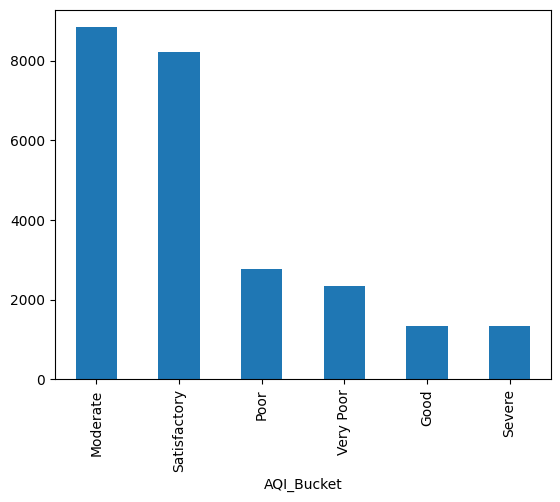

In [ ]:
city_day['AQI_Bucket'].value_counts().plot.bar()

In [ ]:
# crear objeto OrdinalEncoder
encoder = OrdinalEncoder()

# seleccionar los not null
nonulls = city_day['AQI_Bucket']
nonulls = nonulls[nonulls.notnull()]

# reshapes los datos para encoding
impute_reshape = nonulls.values.reshape(-1,1)
impute_reshape

#encode dato
impute_ordinal = encoder.fit_transform(impute_reshape)
impute_ordinal

#Asignar valores codificados nuevamente a valores no nulos
nonulls.loc[nonulls.notnull()] = np.squeeze(impute_ordinal)

In [ ]:
nonulls

,AQI_Bucket
Date,
2015-01-29,2.0
2015-01-30,5.0
2015-01-31,4.0
2015-02-01,4.0
2015-02-02,4.0
...,...
2020-06-27,0.0
2020-06-28,3.0
2020-06-29,3.0


In [ ]:
def encode(data,encoder):

    # seleccionar los not null

    nonulls = data[data.notnull()]


    # reshapes los datos para encoding
    impute_reshape = nonulls.values.reshape(-1,1)


    #encode dato
    impute_ordinal = encoder.fit_transform(impute_reshape)


    #Asignar valores codificados nuevamente a valores no nulos
    data.loc[data.notnull()] = np.squeeze(impute_ordinal)

    return data

In [ ]:
# Para todas las variables categoricas
city_day_knn = city_day.copy(deep=True)
ordinal_enc_dic  = {}

encoder_ord = OrdinalEncoder()
for col_name in missing_categoricas:
  # encoder para cada variable
  ordinal_enc_dic[col_name] = OrdinalEncoder()
  encode(city_day_knn[col_name],ordinal_enc_dic[col_name])



<ipython-input-152-a9c5403e366c>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[data.notnull()] = np.squeeze(impute_ordinal)


In [ ]:
city_day_knn['AQI_Bucket'].loc[city_day_knn['AQI_Bucket'].notnull()]


,AQI_Bucket
Date,
2015-01-29,2.0
2015-01-30,5.0
2015-01-31,4.0
2015-02-01,4.0
2015-02-02,4.0
...,...
2020-06-27,0.0
2020-06-28,3.0
2020-06-29,3.0


In [ ]:
city_day_knn.columns

Index(['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [ ]:
# imputamos
knn_imputer = KNNImputer(n_neighbors = 3) # , weights="uniform"
city_day_knn.iloc[:,1:]  = np.round(knn_imputer.fit_transform(city_day_knn.iloc[:,1:] ))


In [ ]:
city_day_knn.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
Date,,,,,,,,,,,,,,,
2015-01-01,Ahmedabad,27.0,186.0,1.0,18.0,17.0,10.0,1.0,28.0,133.0,0.0,0.0,0.0,101.0,2.0
2015-01-02,Ahmedabad,24.0,164.0,1.0,16.0,16.0,10.0,1.0,25.0,34.0,4.0,6.0,4.0,121.0,2.0
2015-01-03,Ahmedabad,78.0,182.0,17.0,19.0,30.0,9.0,17.0,29.0,31.0,7.0,16.0,2.0,205.0,3.0
2015-01-04,Ahmedabad,43.0,229.0,2.0,18.0,18.0,10.0,2.0,19.0,36.0,4.0,10.0,1.0,153.0,1.0
2015-01-05,Ahmedabad,136.0,259.0,22.0,21.0,38.0,9.0,22.0,39.0,39.0,7.0,19.0,3.0,324.0,3.0


In [ ]:
city_day_knn.isnull().mean()*100

,0
City,0.0
PM2.5,0.0
PM10,0.0
NO,0.0
NO2,0.0
NOx,0.0
NH3,0.0
CO,0.0
SO2,0.0
O3,0.0


In [ ]:
for col_name in missing_categoricas:
    # reshapes los datos para encoding
    reshape = city_day_knn[col_name].values.reshape(-1,1)
    city_day_knn.loc[:,col_name] = ordinal_enc_dic['AQI_Bucket'].inverse_transform(reshape) # inverse_transform devuelve un numpy.ndarray


In [ ]:
city_day_knn.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
Date,,,,,,,,,,,,,,,
2015-01-01,Ahmedabad,27.0,186.0,1.0,18.0,17.0,10.0,1.0,28.0,133.0,0.0,0.0,0.0,101.0,Poor
2015-01-02,Ahmedabad,24.0,164.0,1.0,16.0,16.0,10.0,1.0,25.0,34.0,4.0,6.0,4.0,121.0,Poor
2015-01-03,Ahmedabad,78.0,182.0,17.0,19.0,30.0,9.0,17.0,29.0,31.0,7.0,16.0,2.0,205.0,Satisfactory
2015-01-04,Ahmedabad,43.0,229.0,2.0,18.0,18.0,10.0,2.0,19.0,36.0,4.0,10.0,1.0,153.0,Moderate
2015-01-05,Ahmedabad,136.0,259.0,22.0,21.0,38.0,9.0,22.0,39.0,39.0,7.0,19.0,3.0,324.0,Satisfactory


**Pros**

- Rápido y fácil

- Anda bien con datasets numéricos bien balanceados.

**Cons**

- Usa distancias calculadas usando los casos, aun cuando tengan NaN's, pero deben ser todas variables numericas.

- Antes de imputar, hay que codificar las variables, usando HotEncoding, LabelEncoding o OrdinalEncoding

- KNN Imputer precisa que los datos esten estandarizados. Datos con diferentes escalas introducen valores de reemplazo sesgados   Scikit-Learn’s MinMaxScaler escala las variables al [0,1].

- No es muy preciso, y no hay computo para el error.

- CouncilArea no puede ser imputada sin realizar encoding primero.

#### Multivariate feature imputation - Imputación multivariante por ecuaciones encadenadas (MICE - ‘Multiple Imputation by Chained Equation)
Una estrategia para imputar valores ausentes es modelando cada característica con valores ausentes como una función de otras características con valores presentes de forma rotatoria. Realiza regresiones múltiples sobre una muestra aleatoria de los datos, luego toma el promedio de los valores de regresión múltiple y utiliza ese valor para imputar el valor que falta.

Este tipo de imputación funciona llenando los datos faltantes varias veces. Las imputaciones múltiples (IM) son mucho mejores que una sola imputación, ya que mide la incertidumbre de los valores perdidos de una mejor manera. El enfoque de ecuaciones encadenadas también es muy flexible y puede manejar diferentes variables de diferentes tipos de datos (es decir, continuos o binarios), así como complejidades como límites o patrones de omisión de encuestas.

La version de Sklearn no permite trabajar con variables de distinto tipo, hay que realizar encoding. En sklearn, se implementa de la siguiente manera:



In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


In [ ]:
city_day_mice = city_day.copy(deep=True)


In [ ]:
missing_mask = city_day.isna()
city_day_mice[missing_mask.any(axis=1)].head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
Date,,,,,,,,,,,,,,,
2015-01-01,Ahmedabad,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
2015-01-02,Ahmedabad,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2015-01-03,Ahmedabad,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
2015-01-04,Ahmedabad,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
2015-01-05,Ahmedabad,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
?IterativeImputer

In [ ]:
# creamos objeto de imputación mice
mice_imputer = IterativeImputer()
city_day_mice['Xylene'] = mice_imputer.fit_transform(city_day_mice[['Xylene']])

In [ ]:
city_day['Xylene'].describe()

,Xylene
count,11422.000000
mean,3.070128
std,6.323247
min,0.000000
25%,0.140000
50%,0.980000
75%,3.350000
max,170.370000


In [ ]:
city_day_mice['Xylene'][50:70]

,Xylene
Date,
2015-02-20,7.480000
2015-02-21,15.440000
2015-02-22,8.470000
2015-02-23,28.460000
2015-02-24,6.050000
2015-02-25,0.810000
2015-02-26,3.070128
2015-02-27,3.070128
2015-02-28,3.070128


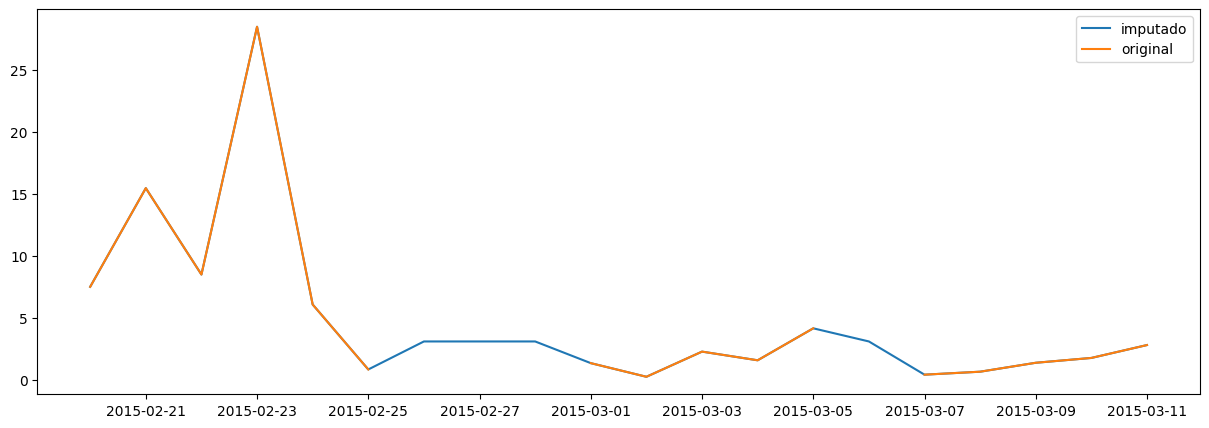

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(city_day_mice['Xylene'][50:70], label = "imputado")
plt.plot(city_day['Xylene'][50:70], label = "original")
plt.legend()
plt.show()

In [ ]:
city_day_mice['Xylene'].isnull().sum()

np.int64(0)

**Pros**

- Versatil, puede utilizarse con diferentes clases de clasificadores

**Cons**

- La version de Sklearn no admite datos mixtos, debe realizarse un encoding primero.

## Conclusión

 No existe una forma perfecta de compensar los valores perdidos en un conjunto de datos. Cada estrategia puede funcionar mejor para ciertos conjuntos de datos y tipos de datos faltantes, pero puede funcionar mucho peor en otros tipos de conjuntos de datos. Hay algunas reglas establecidas para decidir qué estrategia usar para tipos particulares de valores perdidos, pero más allá de eso, debe experimentar y verificar qué modelo funciona mejor para su conjunto de datos.